In [1]:
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import skorch
from skorch import NeuralNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from torch.utils.data import Dataset, DataLoader

from helper_code import find_records, get_age, get_sex, load_header, get_label, load_signals

In [2]:
%load_ext autoreload

%autoreload 2

SEED = 42
BATCH_SIZE = 32

In [3]:
def get_features_and_labels(records_id: str, data_folder: Path):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path)
    signals, fields = load_signals(record_path)
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    return signals, label, age, sex

In [33]:
class ECGDataset(Dataset):
    def __init__(self, features, labels, max_len: int=4096):
        self.features = features
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if signals.size(0) < self.max_len:
            signals = torch.cat([signals, torch.zeros(self.max_len - signals.size(0), signals.size(1))])

        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)

        return signals, label

In [5]:
train_data_folder = Path('code15_wfdb')

In [6]:
train_records = find_records(train_data_folder.absolute().__str__())

In [7]:
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder) for record_id in tqdm(train_records, desc='Loading signals'))

Loading signals: 100%|██████████| 13092/13092 [00:24<00:00, 532.00it/s]


In [8]:
features, labels, ages, sexes = zip(*data)
features = [f for f in features]

In [34]:
X, y = features, np.array(labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED)

In [78]:
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dloader = DataLoader(val_dataset, shuffle=False)
test_dloader = DataLoader(test_dataset, shuffle=False)

valid_ds = skorch.dataset.Dataset(ECGDataset(X, y))

In [160]:
import torch.nn.functional as F

class MyConv1dPadSame(nn.Module):
    """
    extend nn.Conv1d to support SAME padding

    input: (n_sample, in_channels, n_length)
    output: (n_sample, out_channels, (n_length+stride-1)//stride)
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, groups=1):
        super(MyConv1dPadSame, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups = groups
        self.conv = torch.nn.Conv1d(
            in_channels=self.in_channels, 
            out_channels=self.out_channels, 
            kernel_size=self.kernel_size, 
            stride=self.stride, 
            groups=self.groups)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        in_dim = net.shape[-1]
        out_dim = (in_dim + self.stride - 1) // self.stride
        p = max(0, (out_dim - 1) * self.stride + self.kernel_size - in_dim)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.conv(net)

        return net
        
class MyMaxPool1dPadSame(nn.Module):
    """
    extend nn.MaxPool1d to support SAME padding

    params:
        kernel_size: kernel size
        stride: the stride of the window. Default value is kernel_size
    
    input: (n_sample, n_channel, n_length)
    """
    def __init__(self, kernel_size):
        super(MyMaxPool1dPadSame, self).__init__()
        self.kernel_size = kernel_size
        self.max_pool = torch.nn.MaxPool1d(kernel_size=self.kernel_size)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        p = max(0, self.kernel_size - 1)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.max_pool(net)
        
        return net
    
class Swish(nn.Module):
    def forward(self, x):
        return x * F.sigmoid(x)

class BasicBlock(nn.Module):
    """
    Basic Block: 
        conv1 -> convk -> conv1

    params:
        in_channels: number of input channels
        out_channels: number of output channels
        ratio: ratio of channels to out_channels
        kernel_size: kernel window length
        stride: kernel step size
        groups: number of groups in convk
        downsample: whether downsample length
        use_bn: whether use batch_norm
        use_do: whether use dropout

    input: (n_sample, in_channels, n_length)
    output: (n_sample, out_channels, (n_length+stride-1)//stride)
    """
    def __init__(self, in_channels, out_channels, ratio, kernel_size, stride, groups, downsample, is_first_block=False, use_bn=True, use_do=True):
        super(BasicBlock, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.groups = groups
        self.downsample = downsample
        self.stride = stride if self.downsample else 1
        self.is_first_block = is_first_block
        self.use_bn = use_bn
        self.use_do = use_do

        self.middle_channels = int(self.out_channels * self.ratio)

        # the first conv, conv1
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.activation1 = Swish()
        self.do1 = nn.Dropout(p=0.5)
        self.conv1 = MyConv1dPadSame(
            in_channels=self.in_channels, 
            out_channels=self.middle_channels, 
            kernel_size=1, 
            stride=1,
            groups=1)

        # the second conv, convk
        self.bn2 = nn.BatchNorm1d(self.middle_channels)
        self.activation2 = Swish()
        self.do2 = nn.Dropout(p=0.5)
        self.conv2 = MyConv1dPadSame(
            in_channels=self.middle_channels, 
            out_channels=self.middle_channels, 
            kernel_size=self.kernel_size, 
            stride=self.stride,
            groups=self.groups)

        # the third conv, conv1
        self.bn3 = nn.BatchNorm1d(self.middle_channels)
        self.activation3 = Swish()
        self.do3 = nn.Dropout(p=0.5)
        self.conv3 = MyConv1dPadSame(
            in_channels=self.middle_channels, 
            out_channels=self.out_channels, 
            kernel_size=1, 
            stride=1,
            groups=1)

        # Squeeze-and-Excitation
        r = 2
        self.se_fc1 = nn.Linear(self.out_channels, self.out_channels//r)
        self.se_fc2 = nn.Linear(self.out_channels//r, self.out_channels)
        self.se_activation = Swish()

        if self.downsample:
            self.max_pool = MyMaxPool1dPadSame(kernel_size=self.stride)

    def forward(self, x):
        
        identity = x
        
        out = x
        # the first conv, conv1
        if not self.is_first_block:
            if self.use_bn:
                out = self.bn1(out)
            out = self.activation1(out)
            if self.use_do:
                out = self.do1(out)
        out = self.conv1(out)
        
        # the second conv, convk
        if self.use_bn:
            out = self.bn2(out)
        out = self.activation2(out)
        if self.use_do:
            out = self.do2(out)
        out = self.conv2(out)
        
        # the third conv, conv1
        if self.use_bn:
            out = self.bn3(out)
        out = self.activation3(out)
        if self.use_do:
            out = self.do3(out)
        out = self.conv3(out) # (n_sample, n_channel, n_length)

        # Squeeze-and-Excitation
        se = out.mean(-1) # (n_sample, n_channel)
        se = self.se_fc1(se)
        se = self.se_activation(se)
        se = self.se_fc2(se)
        se = F.sigmoid(se) # (n_sample, n_channel)
        out = torch.einsum('abc,ab->abc', out, se)
        
        # if downsample, also downsample identity
        if self.downsample:
            identity = self.max_pool(identity)
            
        # if expand channel, also pad zeros to identity
        if self.out_channels != self.in_channels:
            identity = identity.transpose(-1,-2)
            ch1 = (self.out_channels-self.in_channels)//2
            ch2 = self.out_channels-self.in_channels-ch1
            identity = F.pad(identity, (ch1, ch2), "constant", 0)
            identity = identity.transpose(-1,-2)
        
        # shortcut
        out += identity

        return out

class BasicStage(nn.Module):
    """
    Basic Stage:
        block_1 -> block_2 -> ... -> block_M
    """
    def __init__(self, in_channels, out_channels, ratio, kernel_size, stride, groups, i_stage, m_blocks, use_bn=True, use_do=True, verbose=False):
        super(BasicStage, self).__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.groups = groups
        self.i_stage = i_stage
        self.m_blocks = m_blocks
        self.use_bn = use_bn
        self.use_do = use_do
        self.verbose = verbose

        self.block_list = nn.ModuleList()
        for i_block in range(self.m_blocks):
            
            # first block
            if self.i_stage == 0 and i_block == 0:
                self.is_first_block = True
            else:
                self.is_first_block = False
            # downsample, stride, input
            if i_block == 0:
                self.downsample = True
                self.stride = stride
                self.tmp_in_channels = self.in_channels
            else:
                self.downsample = False
                self.stride = 1
                self.tmp_in_channels = self.out_channels
            
            # build block
            tmp_block = BasicBlock(
                in_channels=self.tmp_in_channels, 
                out_channels=self.out_channels, 
                ratio=self.ratio, 
                kernel_size=self.kernel_size, 
                stride=self.stride, 
                groups=self.groups, 
                downsample=self.downsample, 
                is_first_block=self.is_first_block,
                use_bn=self.use_bn, 
                use_do=self.use_do)
            self.block_list.append(tmp_block)

    def forward(self, x):

        out = x

        for i_block in range(self.m_blocks):
            net = self.block_list[i_block]
            out = net(out)
            if self.verbose:
                print('stage: {}, block: {}, in_channels: {}, out_channels: {}, outshape: {}'.format(self.i_stage, i_block, net.in_channels, net.out_channels, list(out.shape)))
                print('stage: {}, block: {}, conv1: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv1.in_channels, net.conv1.out_channels, net.conv1.kernel_size, net.conv1.stride, net.conv1.groups))
                print('stage: {}, block: {}, convk: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv2.in_channels, net.conv2.out_channels, net.conv2.kernel_size, net.conv2.stride, net.conv2.groups))
                print('stage: {}, block: {}, conv1: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv3.in_channels, net.conv3.out_channels, net.conv3.kernel_size, net.conv3.stride, net.conv3.groups))

        return out

class Net1D(nn.Module):
    """
    
    Input:
        X: (n_samples, n_channel, n_length)
        Y: (n_samples)
        
    Output:
        out: (n_samples)
        
    params:
        in_channels
        base_filters
        filter_list: list, filters for each stage
        m_blocks_list: list, number of blocks of each stage
        kernel_size
        stride
        groups_width
        n_stages
        n_classes
        use_bn
        use_do

    """

    def __init__(self, in_channels, base_filters, ratio, filter_list, m_blocks_list, kernel_size, stride, groups_width, n_classes, use_bn=True, use_do=True, verbose=False):
        super(Net1D, self).__init__()
        
        self.in_channels = in_channels
        self.base_filters = base_filters
        self.ratio = ratio
        self.filter_list = filter_list
        self.m_blocks_list = m_blocks_list
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups_width = groups_width
        self.n_stages = len(filter_list)
        self.n_classes = n_classes
        self.use_bn = use_bn
        self.use_do = use_do
        self.verbose = verbose

        # first conv
        self.first_conv = MyConv1dPadSame(
            in_channels=in_channels, 
            out_channels=self.base_filters, 
            kernel_size=self.kernel_size, 
            stride=2)
        self.first_bn = nn.BatchNorm1d(base_filters)
        self.first_activation = Swish()

        # stages
        self.stage_list = nn.ModuleList()
        in_channels = self.base_filters
        for i_stage in range(self.n_stages):

            out_channels = self.filter_list[i_stage]
            m_blocks = self.m_blocks_list[i_stage]
            tmp_stage = BasicStage(
                in_channels=in_channels, 
                out_channels=out_channels, 
                ratio=self.ratio, 
                kernel_size=self.kernel_size, 
                stride=self.stride, 
                groups=out_channels//self.groups_width, 
                i_stage=i_stage,
                m_blocks=m_blocks, 
                use_bn=self.use_bn, 
                use_do=self.use_do, 
                verbose=self.verbose)
            self.stage_list.append(tmp_stage)
            in_channels = out_channels

        # final prediction
        self.dense = nn.Linear(in_channels, n_classes)
        
    def forward(self, x):
        
        out = x
        
        # first conv
        out = self.first_conv(out)
        if self.use_bn:
            out = self.first_bn(out)
        out = self.first_activation(out)
        
        # stages
        for i_stage in range(self.n_stages):
            net = self.stage_list[i_stage]
            out = net(out)

        # final prediction
        out = out.mean(-1)
        out = self.dense(out)
        
        return out

In [161]:
with torch.no_grad():
    torch.cuda.empty_cache()

In [168]:
torch.manual_seed(SEED)

net = NeuralNetClassifier(
    Net1D,
    max_epochs=20,
    lr=1e-3,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    batch_size=32,
    optimizer__weight_decay=1e-3,
    train_split=skorch.dataset.ValidSplit(cv=0.2, stratified=True, random_state=SEED),
    module__in_channels=12,
    module__base_filters=16,
    module__ratio=1,
    module__filter_list = [64, 160, 160, 400, 400, 1024, 1024],
    module__m_blocks_list = [2, 2, 2, 3, 3, 4, 4],
    module__kernel_size=15,
    module__stride=2,
    module__groups_width=16,
    module__n_classes=1,
    callbacks=[
        skorch.callbacks.EarlyStopping(patience=5),
        skorch.callbacks.LRScheduler(policy=torch.optim.lr_scheduler.ReduceLROnPlateau, mode='min', factor=0.1, patience=10),
        skorch.callbacks.EpochScoring(scoring='f1', lower_is_better=False, on_train=False, name='val_f1_score', use_caching=False),
    ]
)

In [169]:
pipe = Pipeline([
    ('net', net),
])

pipe.fit(X=train_dataset, y=y_train)

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB (GPU 0; 3.94 GiB total capacity; 3.72 GiB already allocated; 3.00 MiB free; 3.79 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

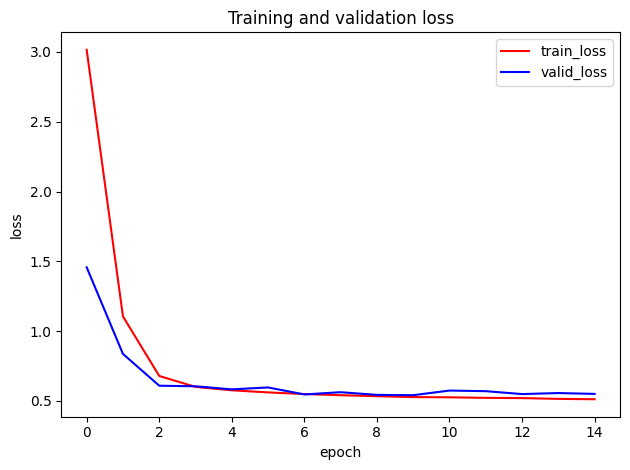

In [ ]:
from matplotlib import pyplot as plt


plt.plot(net.history[:, 'train_loss'], label='train_loss', c='r')
plt.plot(net.history[:, 'valid_loss'], label='valid_loss', c='b')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training and validation loss')
plt.legend()
plt.tight_layout()
plt.show()

In [140]:
y_pred = net.predict(test_dataset)

In [145]:
import pandas as pd


pd.Series(y_pred.flatten()).value_counts()

0    2619
Name: count, dtype: int64

In [147]:
from sklearn.metrics import accuracy_score, f1_score


accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='macro')

(0.49980908743795344, 0.33324847250509165)